## GSEA with Cell Type Signature Gene Sets (Merged by Cell Type)

In [1]:
import pandas as pd
import gseapy as gp
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist

In [2]:
celltype_gmt_path = "gsea_gene_set/c8.all.v2025.1.Hs.symbols.gmt"  # Your cell type GMT file
spectra_dir = Path("all_datasets_consensus/anal_pc5_c21_S1.filtered_consensus_outputs")
out_dir = Path("gsea_results_celltype_merged")
out_dir.mkdir(parents=True, exist_ok=True)

# === GSEA PARAMETERS ===
min_size = 15
max_size = 500
permutation_num = 1000
seed = 42

# === MERGING OPTIONS ===
min_sources_required = 1  # Minimum number of sources to include a merged cell type
save_merged_gmt = True    # Save the merged GMT file for reuse

### Part 1: Parse and Merge GMT by Cell Type

In [3]:
def parse_gmt(gmt_path: str) -> dict:
    """
    Parse a GMT file into a dictionary.
    
    Returns:
        dict: {gene_set_name: (description, [genes])}
    """
    gene_sets = {}
    with open(gmt_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                name = parts[0]
                description = parts[1]
                genes = [g for g in parts[2:] if g]  # Remove empty strings
                gene_sets[name] = (description, genes)
    return gene_sets

In [4]:
def normalize_celltype(celltype: str) -> str:
    """
    Normalize cell type names for consistent grouping.
    """
    ct = celltype.upper()
    
    # Remove _CELL(S) suffix
    ct = re.sub(r'_CELLS?$', '', ct)
    
    # Standardize plural forms
    if ct.endswith('S') and not ct.endswith('SS'):
        # Check common plural patterns
        singular_mappings = {
            'MVECS': 'MVEC',
            'LSECS': 'LSEC',
            'HSCS': 'HSC',
            'OPCS': 'OPC',
            'NPCS': 'NPC',
            'RPCS': 'RPC',
            'ERYTHROBLASTS': 'ERYTHROBLAST',
            'MEGAKARYOCYTES': 'MEGAKARYOCYTE',
            'LYMPHOCYTES': 'LYMPHOCYTE',
            'MONOCYTES': 'MONOCYTE',
            'MACROPHAGES': 'MACROPHAGE',
            'FIBROBLASTS': 'FIBROBLAST',
            'ASTROCYTES': 'ASTROCYTE',
            'NEURONS': 'NEURON',
            'HEPATOCYTES': 'HEPATOCYTE',
            'CARDIOMYOCYTES': 'CARDIOMYOCYTE',
            'THYMOCYTES': 'THYMOCYTE',
            'PODOCYTES': 'PODOCYTE',
            'PERICYTES': 'PERICYTE',
            'ADIPOCYTES': 'ADIPOCYTE',
            'CHONDROCYTES': 'CHONDROCYTE',
            'OLIGODENDROCYTES': 'OLIGODENDROCYTE',
            'KERATINOCYTES': 'KERATINOCYTE',
            'ENTEROCYTES': 'ENTEROCYTE',
            'COLONOCYTES': 'COLONOCYTE',
            'PNEUMOCYTES': 'PNEUMOCYTE',
            'MELANOCYTES': 'MELANOCYTE',
            'OSTEOCYTES': 'OSTEOCYTE',
            'OSTEOCLASTS': 'OSTEOCLAST',
            'OSTEOBLASTS': 'OSTEOBLAST',
            'SYMPATHOBLASTS': 'SYMPATHOBLAST',
            'HEPATOBLASTS': 'HEPATOBLAST',
            'NEUROBLASTS': 'NEUROBLAST',
        }
        ct = singular_mappings.get(ct, ct)
    
    return ct

In [5]:
def extract_celltype(name: str) -> tuple:
    """
    Extract cell type and source info from gene set name.
    Examples:
        AIZARANI_LIVER_C10_MVECS_1 -> ('MVEC', 'AIZARANI_LIVER')
        DESCARTES_FETAL_KIDNEY_ERYTHROBLASTS -> ('ERYTHROBLAST', 'DESCARTES_FETAL_KIDNEY')
    Returns:
        tuple: (cell_type, source) or (original_name, 'UNKNOWN') if parsing fails
    """
    # Known author prefixes
    authors = [
        'AIZARANI', 'BUSSLINGER', 'CUI', 'DESCARTES', 'DURANTE', 'FAN', 
        'GAO', 'GAUTAM', 'HAY', 'HE_LIM_SUN', 'HU', 'JONES', 'LAKE', 
        'MANNO', 'MENON', 'MURARO', 'RUBENSTEIN', 'SU_HO', 'TRAVAGLINI', 
        'VANGURP', 'ZHENG', 'ZHONG'
    ]
    # Find and remove author prefix
    author = None
    remaining = name
    for a in sorted(authors, key=len, reverse=True):
        if name.startswith(a + '_'):
            author = a
            remaining = name[len(a)+1:]
            break
    if author is None:
        return (name, 'UNKNOWN')
    
    # Tissue/context patterns to remove (order matters - longer first)
    tissue_patterns = [
        # Specific compound patterns first
        (r'^MAIN_FETAL_', 'MAIN_FETAL'),
        (r'^ADULT_OLFACTORY_NEUROEPITHELIUM_', 'ADULT_OLFACTORY_NEUROEPITHELIUM'),
        (r'^BONE_MARROW_CD34_POS_', 'BONE_MARROW_CD34_POS'),
        (r'^CONV_CENT_CHONDROSARCOMA_LEUKOCYTE_', 'CONV_CENT_CHONDROSARCOMA_LEUKOCYTE'),
        (r'^CONV_CENT_CHONDROSARCOMA_STROMAL_', 'CONV_CENT_CHONDROSARCOMA_STROMAL'),
        (r'^CONV_CENT_CHONDROSARCOMA_', 'CONV_CENT_CHONDROSARCOMA'),
        (r'^EYE_CHOROID_SCLERA_', 'EYE_CHOROID_SCLERA'),
        (r'^EYE_IRIS_CILIARY_BODY_', 'EYE_IRIS_CILIARY_BODY'),
        (r'^EYE_CORNEA_', 'EYE_CORNEA'),
        (r'^MIDBRAIN_NEUROTYPES_', 'MIDBRAIN_NEUROTYPES'),
        (r'^DEVELOPING_HEART_', 'DEVELOPING_HEART'),
        (r'^SKELETAL_MUSCLE_', 'SKELETAL_MUSCLE'),
        (r'^EMBRYONIC_CTX_BIG_GROUPS_', 'EMBRYONIC_CTX'),
        (r'^EMBRYONIC_CTX_', 'EMBRYONIC_CTX'),
        (r'^FETAL_ADRENAL_', 'FETAL_ADRENAL'),
        (r'^FETAL_CEREBELLUM_', 'FETAL_CEREBELLUM'),
        (r'^FETAL_CEREBRUM_', 'FETAL_CEREBRUM'),
        (r'^FETAL_EYE_', 'FETAL_EYE'),
        (r'^FETAL_HEART_', 'FETAL_HEART'),
        (r'^FETAL_INTESTINE_', 'FETAL_INTESTINE'),
        (r'^FETAL_KIDNEY_', 'FETAL_KIDNEY'),
        (r'^FETAL_LIVER_', 'FETAL_LIVER'),
        (r'^FETAL_LUNG_', 'FETAL_LUNG'),
        (r'^FETAL_MUSCLE_', 'FETAL_MUSCLE'),
        (r'^FETAL_PANCREAS_', 'FETAL_PANCREAS'),
        (r'^FETAL_PLACENTA_', 'FETAL_PLACENTA'),
        (r'^FETAL_RETINA_', 'FETAL_RETINA'),
        (r'^FETAL_SPLEEN_', 'FETAL_SPLEEN'),
        (r'^FETAL_STOMACH_', 'FETAL_STOMACH'),
        (r'^FETAL_THYMUS_', 'FETAL_THYMUS'),
        (r'^FOETAL_FEMUR_', 'FOETAL_FEMUR'),
        (r'^ADULT_KIDNEY_', 'ADULT_KIDNEY'),
        (r'^BONE_MARROW_', 'BONE_MARROW'),
        (r'^CORD_BLOOD_', 'CORD_BLOOD'),
        (r'^LARGE_INTESTINE_ADULT_', 'LARGE_INTESTINE_ADULT'),
        (r'^LARGE_INTESTINE_24W_', 'LARGE_INTESTINE_24W'),
        (r'^SMALL_INTESTINE_24W_', 'SMALL_INTESTINE_24W'),
        (r'^ESOPHAGUS_25W_', 'ESOPHAGUS_25W'),
        (r'^STOMACH_24W_', 'STOMACH_24W'),
        (r'^PFC_MAJOR_TYPES_', 'PFC'),
        (r'^PFC_', 'PFC'),
        # Simple tissue names
        (r'^LIVER_', 'LIVER'),
        (r'^LUNG_', 'LUNG'),
        (r'^PANCREAS_', 'PANCREAS'),
        (r'^PANCREATIC_', 'PANCREATIC'),
        (r'^DUODENAL_', 'DUODENAL'),
        (r'^ESOPHAGEAL_', 'ESOPHAGEAL'),
        (r'^GASTRIC_', 'GASTRIC'),
        (r'^OVARY_', 'OVARY'),
    ]
    
    tissue = None
    celltype_part = remaining
    for pattern, tissue_name in tissue_patterns:
        if re.match(pattern, remaining):
            tissue = tissue_name
            celltype_part = re.sub(pattern, '', remaining)
            break
    # If no tissue pattern matched, try to extract first component as tissue
    if tissue is None:
        parts = remaining.split('_')
        if len(parts) >= 2:
            tissue = parts[0]
            celltype_part = '_'.join(parts[1:])
        else:
            tissue = 'UNKNOWN'
    
    # Remove cluster identifiers like C10_, C1_, etc.
    celltype_part = re.sub(r'^C\d+_', '', celltype_part)
    # Remove trailing numbers like _1, _2
    celltype_part = re.sub(r'_\d+$', '', celltype_part)
    
    # Normalize cell type name
    celltype_part = normalize_celltype(celltype_part)
    
    source = f"{author}_{tissue}"
    
    return (celltype_part, source)

In [6]:
def merge_gmt_by_celltype(gene_sets: dict, min_sources: int = 1) -> dict:
    """
    Merge gene sets by cell type.
    
    Args:
        gene_sets: Original gene sets from GMT
        min_sources: Minimum number of sources required to include a merged set
    
    Returns:
        dict: {cell_type: {'genes': set, 'sources': list, 'original_names': list}}
    """
    merged = defaultdict(lambda: {'genes': set(), 'sources': set(), 'original_names': []})
    
    for name, (desc, genes) in gene_sets.items():
        celltype, source = extract_celltype(name)
        merged[celltype]['genes'].update(genes)
        merged[celltype]['sources'].add(source)
        merged[celltype]['original_names'].append(name)
    
    # Filter by min_sources and convert sets to lists
    filtered = {}
    for celltype, data in merged.items():
        if len(data['sources']) >= min_sources:
            filtered[celltype] = {
                'genes': sorted(data['genes']),
                'sources': sorted(data['sources']),
                'original_names': data['original_names']
            }
    
    return filtered

In [7]:
def merged_to_gseapy_dict(merged_sets: dict) -> dict:
    """
    Convert merged sets to gseapy-compatible dictionary format.
    
    Returns:
        dict: {gene_set_name: [genes]}
    """
    return {f"MERGED_{celltype}": data['genes'] for celltype, data in merged_sets.items()}

In [8]:
def save_merged_gmt_file(merged_sets: dict, output_path: str):
    """Save merged gene sets to GMT file format."""
    with open(output_path, 'w') as f:
        for celltype in sorted(merged_sets.keys()):
            data = merged_sets[celltype]
            name = f"MERGED_{celltype}"
            desc = f"Merged from {len(data['sources'])} sources"
            genes = '\t'.join(data['genes'])
            f.write(f"{name}\t{desc}\t{genes}\n")
    print(f"Saved merged GMT to: {output_path}")

In [9]:
# Load and parse the original GMT
print(f"Loading GMT: {celltype_gmt_path}")
original_gene_sets = parse_gmt(celltype_gmt_path)
print(f"Original gene sets: {len(original_gene_sets)}")

# Merge by cell type
print(f"\nMerging by cell type (min_sources={min_sources_required})...")
merged_sets = merge_gmt_by_celltype(original_gene_sets, min_sources=min_sources_required)
print(f"Merged cell types: {len(merged_sets)}")

# Convert to gseapy format
gseapy_gene_sets = merged_to_gseapy_dict(merged_sets)

# Optionally save merged GMT
if save_merged_gmt:
    merged_gmt_path = out_dir / "celltype_merged.gmt"
    save_merged_gmt_file(merged_sets, str(merged_gmt_path))

Loading GMT: gsea_gene_set/c8.all.v2025.1.Hs.symbols.gmt
Original gene sets: 866

Merging by cell type (min_sources=1)...
Merged cell types: 559
Saved merged GMT to: gsea_results_celltype_merged/celltype_merged.gmt


In [10]:
# Show merge statistics
print("\n" + "="*70)
print("MERGE STATISTICS")
print("="*70)

gene_counts = [len(data['genes']) for data in merged_sets.values()]
source_counts = [len(data['sources']) for data in merged_sets.values()]

print(f"\nGenes per merged set:")
print(f"  Min: {min(gene_counts)}, Max: {max(gene_counts)}, Mean: {np.mean(gene_counts):.1f}, Median: {np.median(gene_counts):.1f}")

print(f"\nSources per merged set:")
print(f"  Min: {min(source_counts)}, Max: {max(source_counts)}, Mean: {np.mean(source_counts):.1f}, Median: {np.median(source_counts):.1f}")

# Top cell types by source count
print("\nTop 15 cell types by number of sources:")
sorted_by_sources = sorted(merged_sets.items(), key=lambda x: len(x[1]['sources']), reverse=True)
for celltype, data in sorted_by_sources[:15]:
    print(f"  {celltype}: {len(data['sources'])} sources, {len(data['genes'])} genes")


MERGE STATISTICS

Genes per merged set:
  Min: 5, Max: 1959, Mean: 247.5, Median: 145.0

Sources per merged set:
  Min: 1, Max: 17, Mean: 1.5, Median: 1.0

Top 15 cell types by number of sources:
  VASCULAR_ENDOTHELIAL: 17 sources, 1378 genes
  STROMAL: 16 sources, 1418 genes
  MYELOID: 13 sources, 942 genes
  LYMPHOID: 12 sources, 623 genes
  ERYTHROBLAST: 11 sources, 1765 genes
  MEGAKARYOCYTE: 11 sources, 1457 genes
  SMOOTH_MUSCLE: 10 sources, 986 genes
  LYMPHATIC_ENDOTHELIAL: 8 sources, 559 genes
  MESOTHELIAL: 8 sources, 1135 genes
  MICROGLIA: 7 sources, 1959 genes
  GOBLET: 6 sources, 283 genes
  ENDOTHELIAL: 6 sources, 864 genes
  ASTROCYTE: 6 sources, 1143 genes
  SCHWANN: 5 sources, 340 genes
  MONOCYTE: 5 sources, 734 genes


In [11]:
print("\n" + "="*70)
print("Some examples")
print("="*70)

example_celltypes = ['ERYTHROBLAST', 'MACROPHAGE', 'ENDOTHELIAL', 'FIBROBLAST', 'T_LYMPHOCYTE']

for ct in example_celltypes:
    if ct in merged_sets:
        data = merged_sets[ct]
        print(f"\n{ct}:")
        print(f"  Total genes: {len(data['genes'])}")
        print(f"  Sources ({len(data['sources'])}): {', '.join(data['sources'][:5])}{'...' if len(data['sources']) > 5 else ''}")
        print(f"  Original sets merged: {len(data['original_names'])}")


Some examples

ERYTHROBLAST:
  Total genes: 1765
  Sources (11): DESCARTES_FETAL_ADRENAL, DESCARTES_FETAL_HEART, DESCARTES_FETAL_INTESTINE, DESCARTES_FETAL_KIDNEY, DESCARTES_FETAL_LIVER...
  Original sets merged: 11

MACROPHAGE:
  Total genes: 660
  Sources (4): CUI_DEVELOPING_HEART, DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM, JONES_OVARY, TRAVAGLINI_LUNG
  Original sets merged: 4

ENDOTHELIAL:
  Total genes: 864
  Sources (6): CUI_DEVELOPING_HEART, JONES_OVARY, MURARO_PANCREAS, RUBENSTEIN_SKELETAL_MUSCLE, SU_HO_CONV_CENT_CHONDROSARCOMA_STROMAL...
  Original sets merged: 6

FIBROBLAST:
  Total genes: 903
  Sources (5): GAUTAM_EYE_CHOROID_SCLERA, GAUTAM_EYE_CORNEA, GAUTAM_EYE_IRIS_CILIARY_BODY, HU_FETAL_RETINA, SU_HO_FOETAL_FEMUR
  Original sets merged: 5


### Part 2: Find Spectra Files and Run GSEA

In [12]:
# Find spectra score files
pattern = re.compile(r"\.gene_spectra_score\.k_(\d+)\.dt_0_01\.txt$")

spectra_files = []
for fp in spectra_dir.glob("*.gene_spectra_score.k_*.dt_0_01.txt"):
    m = pattern.search(fp.name)
    if m:
        K = int(m.group(1))
        spectra_files.append((K, fp))

if not spectra_files:
    raise FileNotFoundError(f"No spectra files found in {spectra_dir}")

spectra_files.sort(key=lambda x: x[0])

print(f"Found {len(spectra_files)} spectra files")
print(f"K values: {[k for k, _ in spectra_files]}")

Found 17 spectra files
K values: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]


In [13]:
# Run GSEA for all K values and GEPs
all_rows = []

for K, fp in spectra_files:
    print(f"Processing K={K}: {fp.name}")
    spectra = pd.read_csv(fp, sep="\t", index_col=0)  # rows=GEPs, cols=genes
    spectra.columns = spectra.columns.astype(str)
    
    for gep in spectra.index:
        # Create preranked list: genes sorted by score
        rnk = spectra.loc[gep].sort_values(ascending=False)
        
        # Run GSEA prerank with merged cell type gene sets
        prerank_res = gp.prerank(
            rnk=rnk,
            gene_sets=gseapy_gene_sets,  # Using the merged dictionary
            min_size=min_size,
            max_size=max_size,
            permutation_num=permutation_num,
            seed=seed,
            outdir=None,
            verbose=False
        )
        
        res = prerank_res.res2d.copy()
        res["K"] = K
        res["GEP"] = str(gep)
        res["spectra_file"] = fp.name
        
        all_rows.append(res)

print("\nGSEA complete! ✅")

2026-01-15 15:07:14,146 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Processing K=5: anal_pc5_c21_S1.filtered.gene_spectra_score.k_5.dt_0_01.txt


2026-01-15 15:07:16,161 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:07:18,158 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:07:20,192 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:07:22,185 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:07:24,187 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Processing K=6: anal_pc5_c21_S1.filtered.gene_spectra_score.k_6.dt_0_01.txt


2026-01-15 15:07:26,174 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:07:28,042 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:07:29,947 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:07:31,970 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:07:33,963 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:07:35,932 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be

...

Processing K=20: anal_pc5_c21_S1.filtered.gene_spectra_score.k_20.dt_0_01.txt


2026-01-15 15:12:59,527 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:13:01,376 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:13:03,233 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:13:05,086 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:13:06,925 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:13:08,794 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be

Processing K=21: anal_pc5_c21_S1.filtered.gene_spectra_score.k_21.dt_0_01.txt


2026-01-15 15:13:36,735 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:13:38,646 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:13:40,587 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:13:42,447 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:13:44,301 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-15 15:13:46,166 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be


GSEA complete! ✅


In [14]:
# Combine all results
summary = pd.concat(all_rows, ignore_index=True)

# Standardize column names
col_rename = {
    'Term': 'pathway',
    'NOM p-val': 'pval',
    'FDR q-val': 'fdr',
}
summary.rename(columns={k: v for k, v in col_rename.items() if k in summary.columns}, inplace=True)

# Reorder columns
first_cols = ['K', 'GEP', 'pathway', 'NES', 'pval', 'fdr']
other_cols = [c for c in summary.columns if c not in first_cols]
summary = summary[[c for c in first_cols if c in summary.columns] + other_cols]

print(f"Total results: {len(summary)} rows")
print(f"Columns: {list(summary.columns)}")
summary.head(10)

Total results: 104754 rows
Columns: ['K', 'GEP', 'pathway', 'NES', 'pval', 'fdr', 'Name', 'ES', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes', 'spectra_file']


,K,GEP,pathway,NES,pval,fdr,Name,ES,FWER p-val,Tag %,Gene %,Lead_genes,spectra_file
0,5,1,MERGED_LYMPHOID,3.525934,0.0,0.0,prerank,0.818321,0.0,278/378,16.44%,ARHGEF1;AKNA;ACAP1;CORO1A;TMC8;SEPTIN1;TRAF3IP...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
1,5,1,MERGED_CI_MESENCHYMAL,3.34249,0.0,0.0,prerank,0.803995,0.0,190/261,15.08%,ACAP1;CORO1A;ITGAL;TMC8;ARHGAP15;SEPTIN1;IKZF1...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
2,5,1,MERGED_B_T,3.323489,0.0,0.0,prerank,0.863049,0.0,106/123,11.84%,ARHGEF1;EVL;ACAP1;CORO1A;ITGAL;TMC8;ARHGAP15;S...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
3,5,1,MERGED_BRAIN_NAIVE_LIKE_T,3.276513,0.0,0.0,prerank,0.854714,0.0,93/110,10.88%,ARHGEF1;ACAP1;CORO1A;ARHGAP15;SEPTIN1;TRAF3IP3...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
4,5,1,MERGED_NAIVE_T,3.231388,0.0,0.0,prerank,0.808169,0.0,132/170,15.22%,ARHGEF1;EVL;ACAP1;TMC8;ARHGAP15;SEPTIN1;TRAF3I...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
5,5,1,MERGED_NK_NKT,3.147081,0.0,0.0,prerank,0.748801,0.0,198/308,14.92%,EVL;AKNA;CORO1A;ITGAL;TMC8;IKZF1;WIPF1;TBC1D10...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
6,5,1,MERGED_BRAIN_IMMUNE,3.141356,0.0,0.0,prerank,0.842418,0.0,76/97,10.20%,ARHGEF1;AKNA;ACAP1;CORO1A;ITGAL;TMC8;ARHGAP15;...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
7,5,1,MERGED_BRAIN_EFFECTOR_T,3.101088,0.0,0.0,prerank,0.829512,0.0,86/105,14.14%,AKNA;ACAP1;CORO1A;ITGAL;SEPTIN1;TBC1D10C;RAC2;...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
8,5,1,MERGED_B,3.04203,0.0,0.0,prerank,0.806879,0.0,94/123,13.30%,CORO1A;TBC1D10C;RAC2;LTB;CD53;LIMD2;PTPRC;FCMR...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
9,5,1,MERGED_CD8_NAIVE_T,3.026223,0.0,0.0,prerank,0.810642,0.0,79/102,11.98%,AKNA;ITGAL;SEPTIN1;TBC1D10C;CD2;RASAL3;CD96;ZA...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...


In [15]:
# Save results
output_csv = out_dir / "celltype_gsea_all_K_all_GEPs_tidy.csv"
summary.to_csv(output_csv, index=False)
print(f"Saved results to: {output_csv}")

# Also save per-K files
for K in summary['K'].unique():
    k_data = summary[summary['K'] == K]
    k_path = out_dir / f"K{K}_celltype_gsea.csv"
    k_data.to_csv(k_path, index=False)
print(f"Saved per-K files to: {out_dir}")

Saved results to: gsea_results_celltype_merged/celltype_gsea_all_K_all_GEPs_tidy.csv
Saved per-K files to: gsea_results_celltype_merged


### Part 3: Visualize Results

In [16]:
# Summary statistics
print("RESULTS SUMMARY")
print("="*50)

for K in sorted(summary['K'].unique()):
    k_data = summary[summary['K'] == K]
    n_sig_005 = (k_data['fdr'] < 0.05).sum()
    n_sig_025 = (k_data['fdr'] < 0.25).sum()
    print(f"K={K}: {len(k_data)} total, {n_sig_005} sig (FDR<0.05), {n_sig_025} sig (FDR<0.25)")

RESULTS SUMMARY
K=5: 2370 total, 937 sig (FDR<0.05), 1343 sig (FDR<0.25)
K=6: 2844 total, 1006 sig (FDR<0.05), 1492 sig (FDR<0.25)
K=7: 3318 total, 1125 sig (FDR<0.05), 1649 sig (FDR<0.25)
K=8: 3792 total, 1198 sig (FDR<0.05), 1788 sig (FDR<0.25)
K=9: 4266 total, 1351 sig (FDR<0.05), 2019 sig (FDR<0.25)
K=10: 4740 total, 1464 sig (FDR<0.05), 2265 sig (FDR<0.25)
K=11: 5214 total, 1520 sig (FDR<0.05), 2396 sig (FDR<0.25)
K=12: 5688 total, 1596 sig (FDR<0.05), 2543 sig (FDR<0.25)
K=13: 6162 total, 1648 sig (FDR<0.05), 2812 sig (FDR<0.25)
K=14: 6636 total, 1690 sig (FDR<0.05), 2885 sig (FDR<0.25)
K=15: 7110 total, 1756 sig (FDR<0.05), 3024 sig (FDR<0.25)
K=16: 7584 total, 1844 sig (FDR<0.05), 3017 sig (FDR<0.25)
K=17: 8058 total, 2081 sig (FDR<0.05), 3429 sig (FDR<0.25)
K=18: 8532 total, 1986 sig (FDR<0.05), 3456 sig (FDR<0.25)
K=19: 9006 total, 2469 sig (FDR<0.05), 3850 sig (FDR<0.25)
K=20: 9480 total, 2387 sig (FDR<0.05), 3915 sig (FDR<0.25)
K=21: 9954 total, 2121 sig (FDR<0.05), 3783 si

In [17]:
def plot_gsea_heatmap(data: pd.DataFrame, K: int, fdr_thresh: float = 0.25, 
                      figsize: tuple = (16, 10), top_n: int = None):
    """
    Create a clustered heatmap of GSEA results.
    """
    k_data = data[data['K'] == K].copy()
    k_data['GEP_label'] = 'GEP' + k_data['GEP'].astype(str)
    
    # Pivot for heatmap
    heatmap_data = k_data.pivot_table(
        index='GEP_label',
        columns='pathway',
        values='NES',
        aggfunc='first'
    )
    
    # Filter to significant pathways
    sig_pathways = k_data[k_data['fdr'] < fdr_thresh]['pathway'].unique()
    heatmap_data = heatmap_data[heatmap_data.columns.intersection(sig_pathways)]
    
    if len(heatmap_data.columns) == 0:
        print(f"No significant pathways at FDR < {fdr_thresh} for K={K}")
        return None
    
    # Optionally limit to top N pathways
    if top_n and len(heatmap_data.columns) > top_n:
        max_nes = heatmap_data.abs().max()
        top_pathways = max_nes.nlargest(top_n).index
        heatmap_data = heatmap_data[top_pathways]
    
    # === FIX: Convert to float and handle NaNs ===
    heatmap_data = heatmap_data.astype(float)
    heatmap_data = heatmap_data.fillna(0)
    
    print(f"Plotting {len(heatmap_data.columns)} pathways for K={K}")
    
    # Create clustered heatmap
    g = sns.clustermap(
        heatmap_data,
        cmap='RdBu_r',
        center=0,
        figsize=figsize,
        xticklabels=True,
        yticklabels=True,
        dendrogram_ratio=(0.15, 0.08),
        cbar_pos=(0.02, 0.8, 0.03, 0.15),
        cbar_kws={'label': 'NES'},
        method='ward',
        metric='euclidean',
        row_cluster=True,
        col_cluster=True,
    )
    
    g.ax_heatmap.set_xlabel('Cell Type', fontsize=11)
    g.ax_heatmap.set_ylabel('Gene Expression Program', fontsize=11)
    g.ax_heatmap.tick_params(axis='x', labelsize=7, rotation=90)
    g.ax_heatmap.tick_params(axis='y', labelsize=9)
    
    g.fig.suptitle(f'Cell Type Enrichment × GEPs (K={K}, FDR<{fdr_thresh})', 
                   fontsize=13, y=1.02)
    
    return g

Plotting 451 pathways for K=5


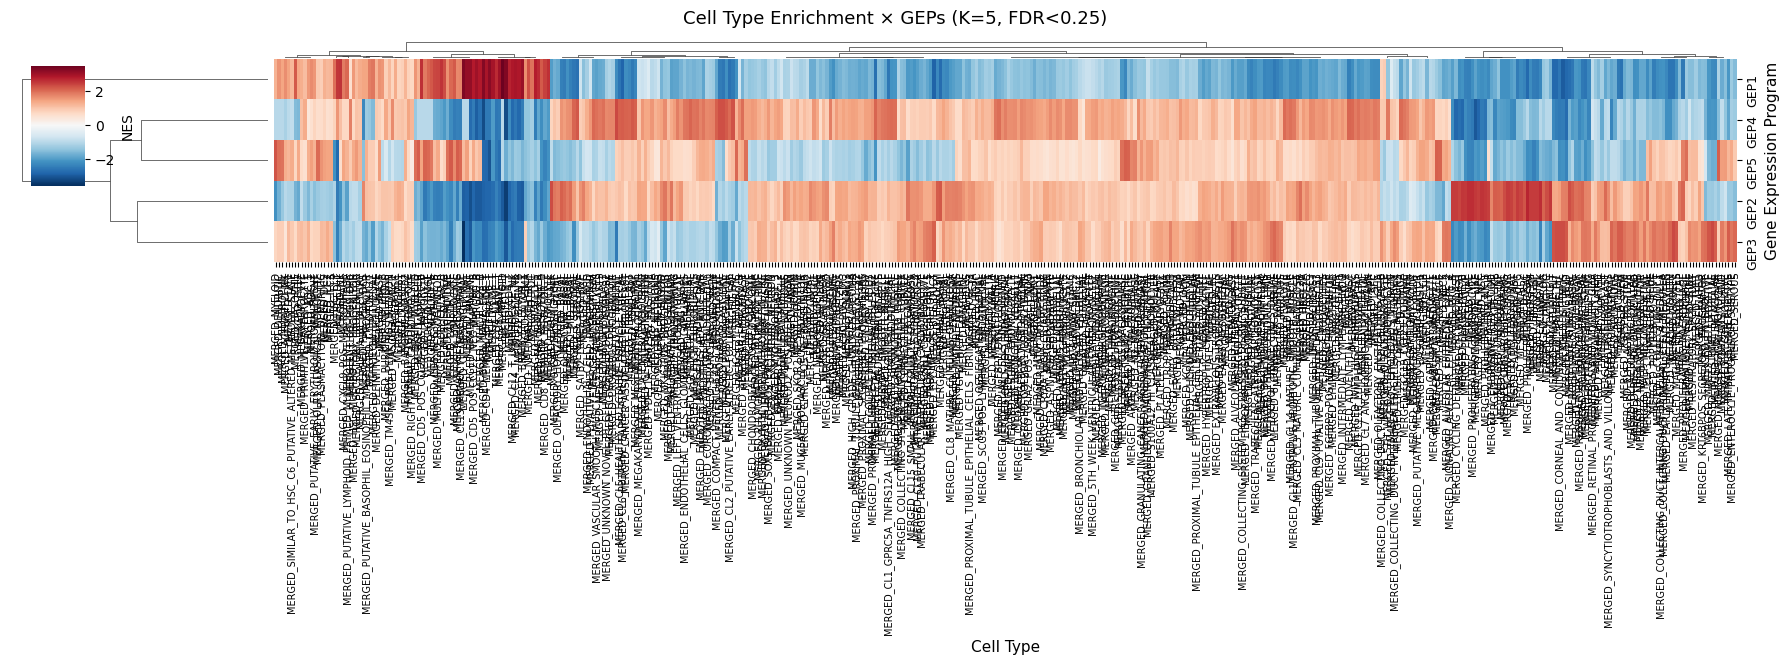

In [18]:
# Plot for K=5 (adjust as needed)
g = plot_gsea_heatmap(summary, K=5, fdr_thresh=0.25, figsize=(18, 8))
if g:
    plt.savefig(out_dir / "K5_celltype_heatmap.png", dpi=150, bbox_inches='tight')
    plt.show()

Plotting 458 pathways for K=6


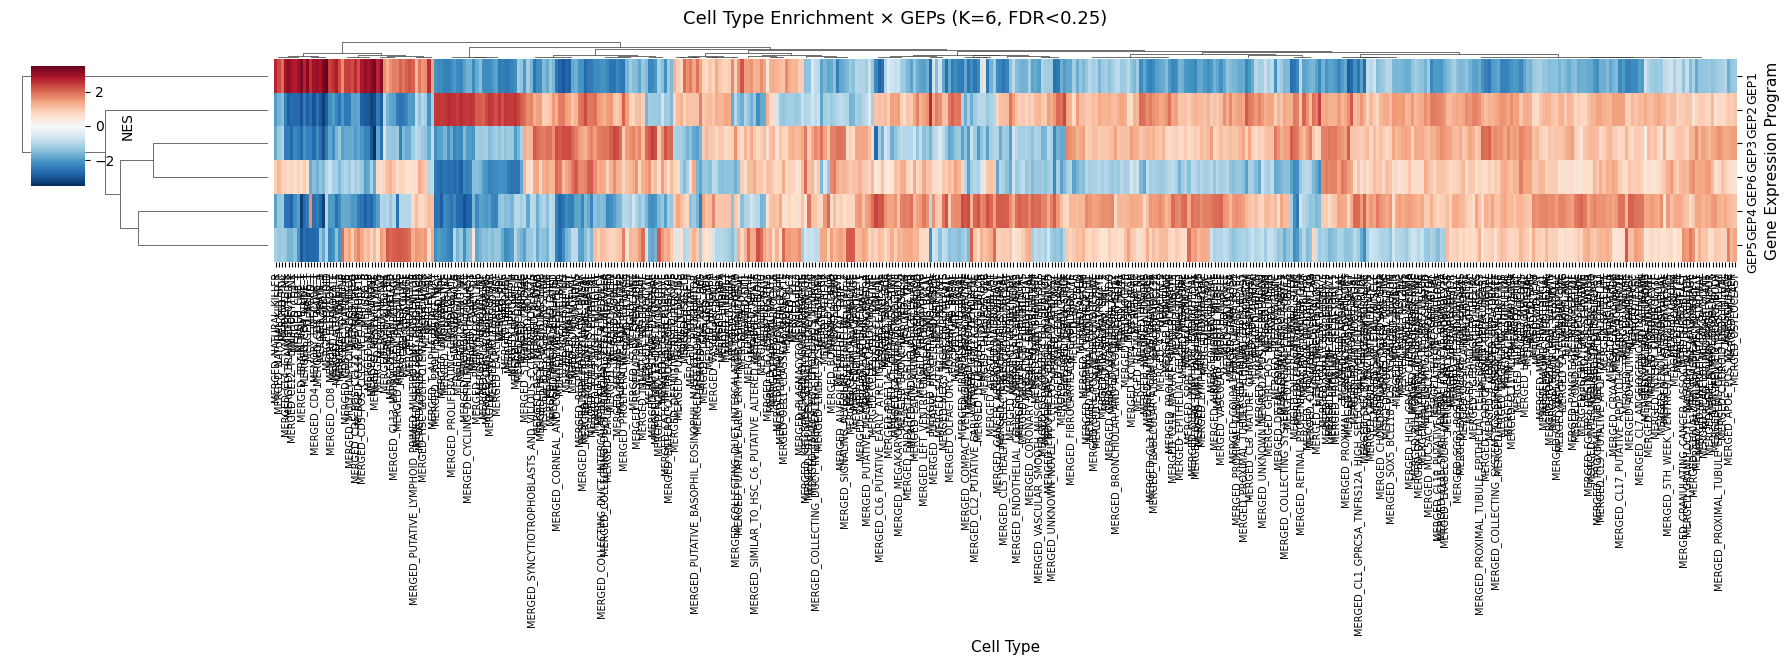

Plotting 457 pathways for K=7


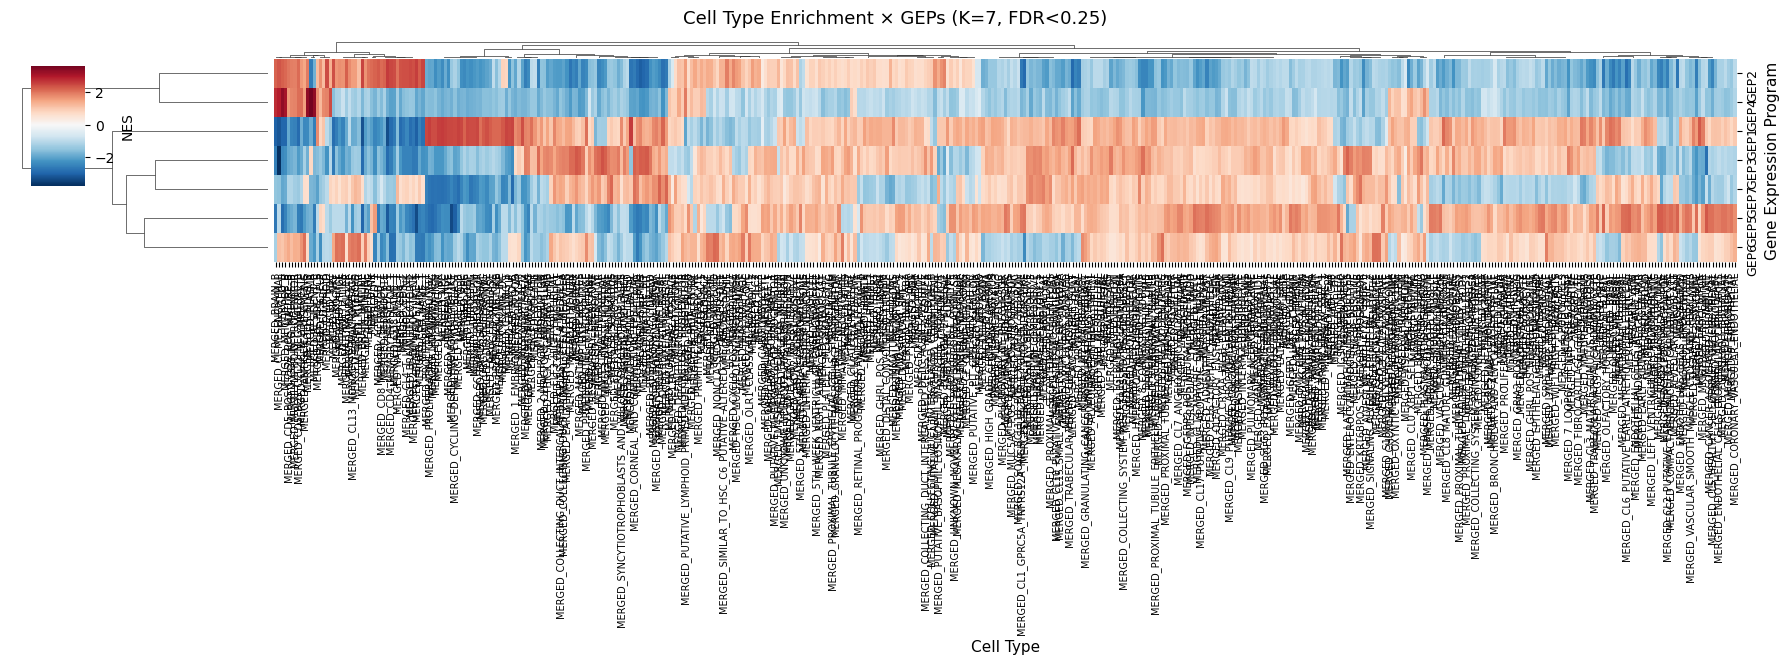

Plotting 457 pathways for K=8


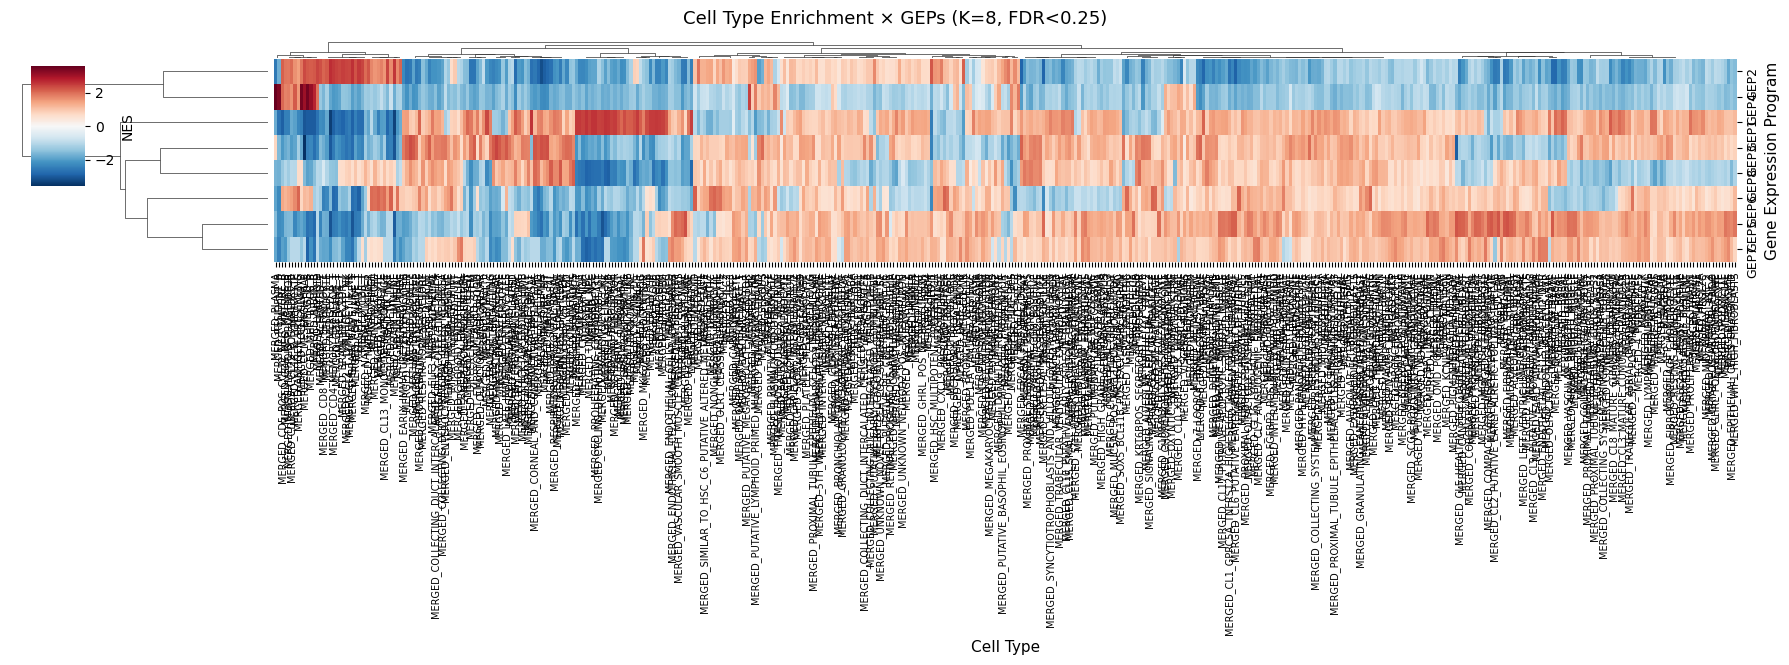

In [19]:
# Plot for multiple K values
for K in [6, 7, 8]:  # Adjust as needed
    if K in summary['K'].values:
        g = plot_gsea_heatmap(summary, K=K, fdr_thresh=0.25, figsize=(18, 8))
        if g:
            plt.savefig(out_dir / f"K{K}_celltype_heatmap.png", dpi=150, bbox_inches='tight')
            plt.show()

In [20]:
# Show top enrichments for a specific K
K_to_show = 5  # Adjust as needed

k_data = summary[summary['K'] == K_to_show].copy()
k_sig = k_data[k_data['fdr'] < 0.25].sort_values('NES', ascending=False)

print(f"\nTop positive enrichments for K={K_to_show} (FDR < 0.25):")
print(k_sig[['GEP', 'pathway', 'NES', 'fdr']].head(20).to_string(index=False))

print(f"\nTop negative enrichments for K={K_to_show} (FDR < 0.25):")
print(k_sig[['GEP', 'pathway', 'NES', 'fdr']].tail(20).to_string(index=False))


Top positive enrichments for K=5 (FDR < 0.25):
GEP                           pathway       NES  fdr
  1                   MERGED_LYMPHOID  3.525934  0.0
  1             MERGED_CI_MESENCHYMAL   3.34249  0.0
  1                        MERGED_B_T  3.323489  0.0
  1         MERGED_BRAIN_NAIVE_LIKE_T  3.276513  0.0
  1                    MERGED_NAIVE_T  3.231388  0.0
  1                     MERGED_NK_NKT  3.147081  0.0
  1               MERGED_BRAIN_IMMUNE  3.141356  0.0
  1           MERGED_BRAIN_EFFECTOR_T  3.101088  0.0
  1                          MERGED_B   3.04203  0.0
  1                MERGED_CD8_NAIVE_T  3.026223  0.0
  1                      MERGED_CD8_T  2.990201  0.0
  1        MERGED_CL4_T_LYMPHOCYTE_NK  2.959796  0.0
  1      MERGED_CD4_MEMORY_EFFECTOR_T  2.952922  0.0
  1                    MERGED_BRAIN_B  2.910087  0.0
  1       MERGED_CL12_T_LYMPHOCYTE_NK  2.905119  0.0
  1               MERGED_MHC_II_POS_B  2.874806  0.0
  1 MERGED_CD5_POS_CCL22_NEG_MATURE_B   2.84981  0.

---
## Notes

**What the merging does:**
- Takes gene sets like `AIZARANI_LIVER_C10_MVECS_1`, `TRAVAGLINI_LUNG_MVEC_CELL` 
- Extracts the cell type: `MVEC`
- Merges genes from all sources → `MERGED_MVEC` with union of all genes

**Why merge?**
- Reduces redundancy (866 → ~200-300 unique cell types)
- More robust signatures (genes consistent across tissues/studies)
- Easier interpretation ("enriched for macrophages" vs "enriched for AIZARANI_LIVER_C2_KUPFFER_CELLS_1")

**Caveats:**
- Merging may lose tissue-specific signal
- Some cell type names may be parsed incorrectly
- Large merged sets may dilute specific signatures